In [2]:
# Cell 1: Import libraries
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)



In [3]:
# Cell 2: Load data from multiple CSV files
folder = r"2012\Dataset"
csv_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".csv")]
df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)

print(f"✅ Loaded {len(csv_files)} files")
print(f"📊 Total rows: {df.shape[0]:,}, Columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

✅ Loaded 11 files
📊 Total rows: 5,591,544, Columns: 64

Column names:
['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_FIPS', 'ORIGIN_STATE_NM', 'ORIGIN_WAC', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEST_STATE_FIPS', 'DEST_STATE_NM', 'DEST_WAC', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15', 'DEP_DELAY_GROUP', 'DEP_TIME_BLK', 'TAXI_OUT', 'WHEELS_OFF', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'ARR_DELAY_GROUP', 'ARR_TIME_BLK', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS', 'DISTANCE', 'DISTANCE_GROUP', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELA

In [4]:
# Check for missing data
df.isnull().sum()

# Check for duplicates
df.duplicated().sum()



np.int64(0)

In [5]:
valid_values = df.notnull().sum().sum()
valid_percentage = (valid_values / df.size) * 100

print(f"Valid values: {valid_percentage:.2f}%")


Valid values: 86.25%


In [6]:
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5591544 entries, 0 to 5591543
Data columns (total 64 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   YEAR                   int64  
 1   QUARTER                int64  
 2   MONTH                  int64  
 3   DAY_OF_MONTH           int64  
 4   DAY_OF_WEEK            int64  
 5   FL_DATE                object 
 6   OP_UNIQUE_CARRIER      object 
 7   OP_CARRIER_AIRLINE_ID  int64  
 8   OP_CARRIER             object 
 9   TAIL_NUM               object 
 10  OP_CARRIER_FL_NUM      int64  
 11  ORIGIN_AIRPORT_ID      int64  
 12  ORIGIN_AIRPORT_SEQ_ID  int64  
 13  ORIGIN_CITY_MARKET_ID  int64  
 14  ORIGIN                 object 
 15  ORIGIN_CITY_NAME       object 
 16  ORIGIN_STATE_ABR       object 
 17  ORIGIN_STATE_FIPS      int64  
 18  ORIGIN_STATE_NM        object 
 19  ORIGIN_WAC             int64  
 20  DEST_AIRPORT_ID        int64  
 21  DEST_AIRPORT_SEQ_ID    int64  
 22  DEST

In [ ]:
#Do preprocessing of the data


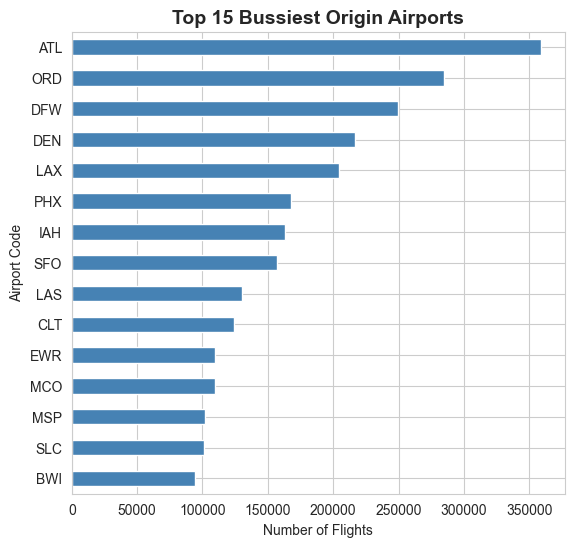

In [7]:
# Cell 4: Top 15 Busiest Origin Airports
plt.figure(figsize=(14, 6))
top_origins = df['ORIGIN'].value_counts().head(15)
plt.subplot(1, 2, 1)
top_origins.plot(kind='barh', color='steelblue')
plt.title('Top 15 Bussiest Origin Airports', fontsize=14, fontweight='bold')
plt.xlabel('Number of Flights')
plt.ylabel('Airport Code')
plt.gca().invert_yaxis()


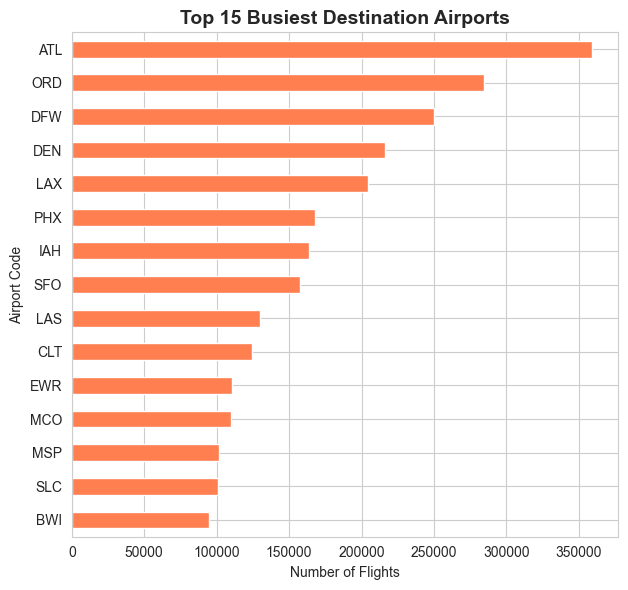

In [8]:
# Top 15 Busiest Destination Airports
plt.subplot(1, 2, 2)
top_dests = df['DEST'].value_counts().head(15)
top_dests.plot(kind='barh', color='coral')
plt.title('Top 15 Busiest Destination Airports', fontsize=14, fontweight='bold')
plt.xlabel('Number of Flights')
plt.ylabel('Airport Code')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

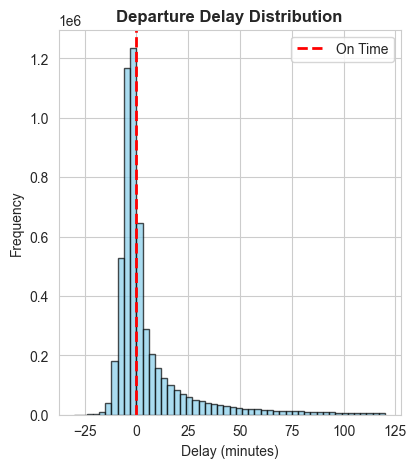

In [9]:
plt.figure(figsize=(15, 5))

# Departure Delay Distribution
plt.subplot(1, 3, 1)
delay_data = df['DEP_DELAY'].dropna()
delay_data = delay_data[(delay_data >= -30) & (delay_data <= 120)]  # Filter outliers
plt.hist(delay_data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='On Time')
plt.title('Departure Delay Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.legend()

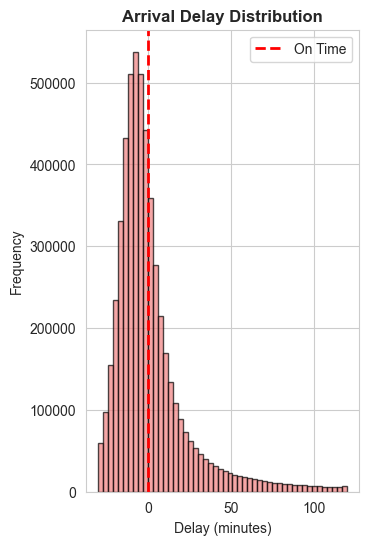

In [10]:
# Arrival Delay Distribution
plt.subplot(1, 3, 2)
arr_delay_data = df['ARR_DELAY'].dropna()
arr_delay_data = arr_delay_data[(arr_delay_data >= -30) & (arr_delay_data <= 120)]
plt.hist(arr_delay_data, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='On Time')
plt.title('Arrival Delay Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.legend()

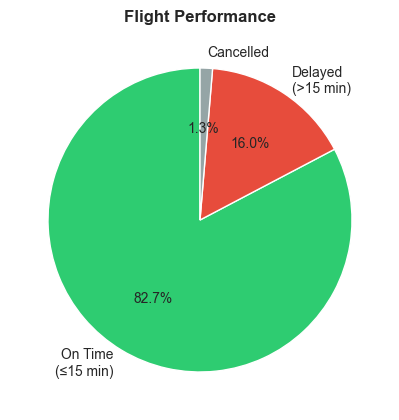

In [11]:
# On-Time Performance
plt.subplot(1, 3, 3)
on_time = (df['DEP_DELAY'] <= 15).sum()
delayed = (df['DEP_DELAY'] > 15).sum()
cancelled = df['CANCELLED'].sum()
labels = ['On Time\n(≤15 min)', 'Delayed\n(>15 min)', 'Cancelled']
sizes = [on_time, delayed, cancelled]
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Flight Performance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'WN'),
  Text(1, 0, 'EV'),
  Text(2, 0, 'DL'),
  Text(3, 0, 'OO'),
  Text(4, 0, 'UA'),
  Text(5, 0, 'AA'),
  Text(6, 0, 'MQ'),
  Text(7, 0, 'US'),
  Text(8, 0, 'B6'),
  Text(9, 0, 'FL')])

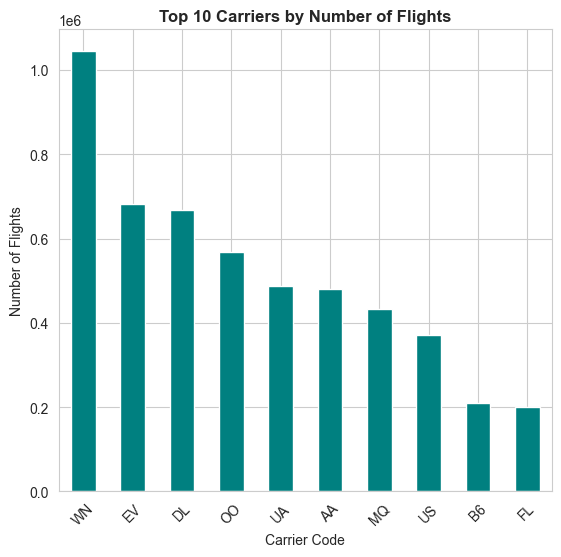

In [12]:
plt.figure(figsize=(14, 6))

# Flights by Carrier
plt.subplot(1, 2, 1)
carrier_counts = df['OP_UNIQUE_CARRIER'].value_counts().head(10)
carrier_counts.plot(kind='bar', color='teal')
plt.title('Top 10 Carriers by Number of Flights', fontsize=12, fontweight='bold')
plt.xlabel('Carrier Code')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)

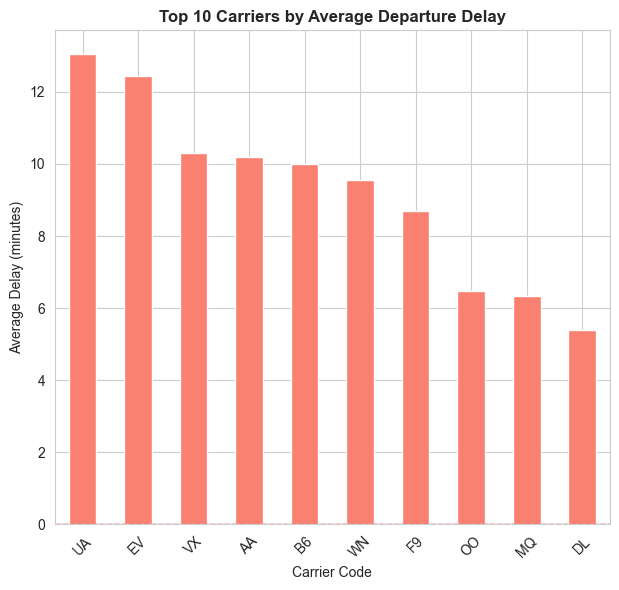

In [13]:
# Average Delay by Carrier
plt.subplot(1, 2, 2)
carrier_delay = df.groupby('OP_UNIQUE_CARRIER')['DEP_DELAY'].mean().sort_values(ascending=False).head(10)
carrier_delay.plot(kind='bar', color='salmon')
plt.title('Top 10 Carriers by Average Departure Delay', fontsize=12, fontweight='bold')
plt.xlabel('Carrier Code')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of Flights')

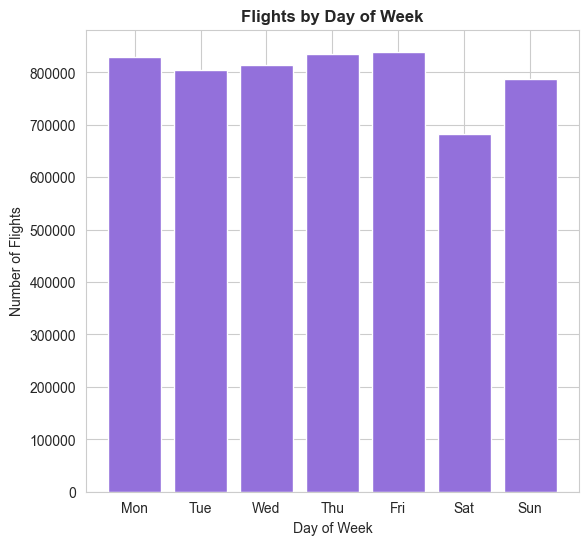

In [14]:
plt.figure(figsize=(14, 6))

day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}

# Flights by Day of Week
plt.subplot(1, 2, 1)
day_counts = df['DAY_OF_WEEK'].value_counts().sort_index()
day_labels = [day_names[d] for d in day_counts.index]
plt.bar(day_labels, day_counts.values, color='mediumpurple')
plt.title('Flights by Day of Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Flights')

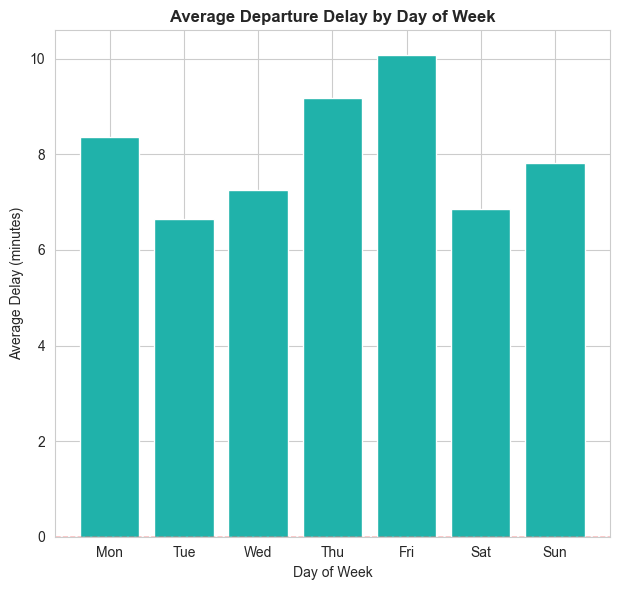

In [15]:
# Average Delay by Day of Week
plt.subplot(1, 2, 2)
day_delay = df.groupby('DAY_OF_WEEK')['DEP_DELAY'].mean().sort_index()
day_delay_labels = [day_names[d] for d in day_delay.index]
plt.bar(day_delay_labels, day_delay.values, color='lightseagreen')
plt.title('Average Departure Delay by Day of Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

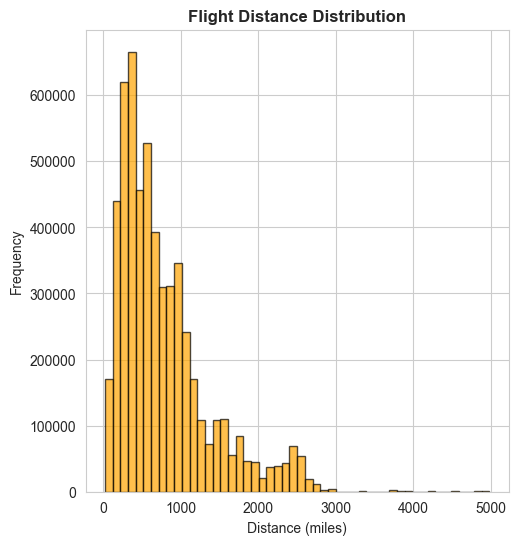

In [16]:
# Distance Distribution
plt.subplot(1, 2, 1)
distance_data = df['DISTANCE'].dropna()
plt.hist(distance_data, bins=50, color='orange', edgecolor='black', alpha=0.7)
plt.title('Flight Distance Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')


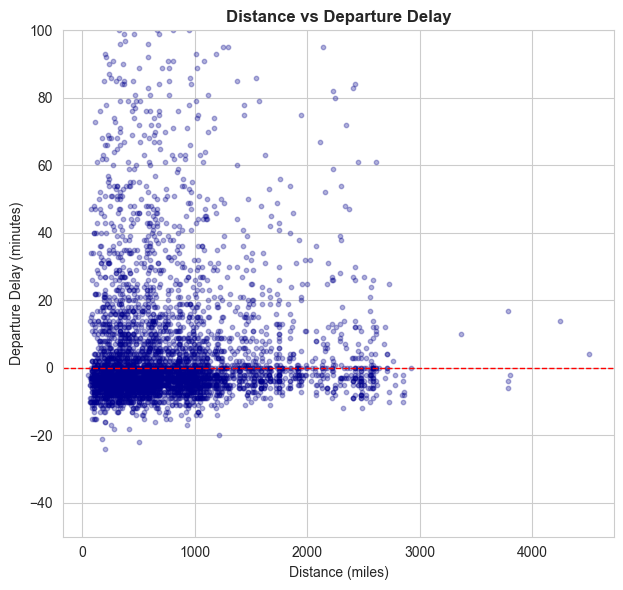

In [17]:
# Distance vs Delay Scatter (sample for performance)
plt.subplot(1, 2, 2)
sample_df = df.dropna(subset=['DISTANCE', 'DEP_DELAY']).sample(min(5000, len(df)))
plt.scatter(sample_df['DISTANCE'], sample_df['DEP_DELAY'], alpha=0.3, s=10, color='darkblue')
plt.title('Distance vs Departure Delay', fontsize=12, fontweight='bold')
plt.xlabel('Distance (miles)')
plt.ylabel('Departure Delay (minutes)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.ylim(-50, 100)
plt.tight_layout()
plt.show()


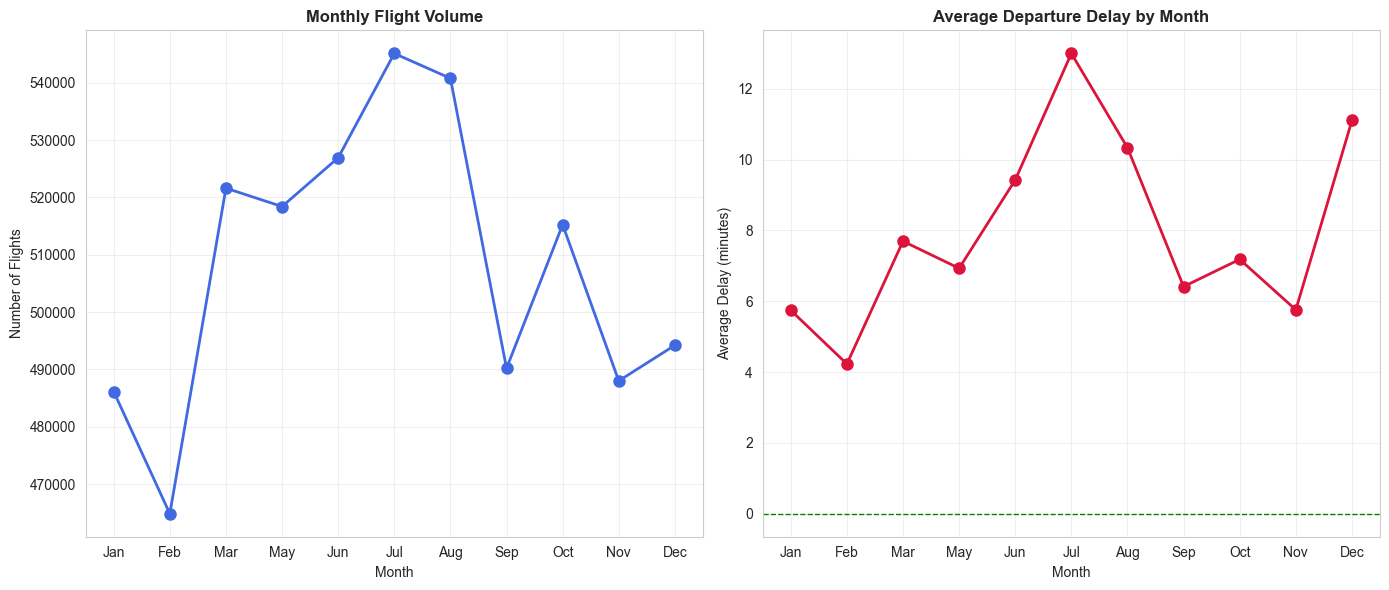

In [18]:
if df['MONTH'].nunique() > 1:
    plt.figure(figsize=(14, 6))
    
    # Flights per Month
    plt.subplot(1, 2, 1)
    month_counts = df['MONTH'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_labels = [month_names[m-1] for m in month_counts.index]
    plt.plot(month_labels, month_counts.values, marker='o', linewidth=2, markersize=8, color='royalblue')
    plt.title('Monthly Flight Volume', fontsize=12, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Number of Flights')
    plt.grid(True, alpha=0.3)
    
    # Average Delay per Month
    plt.subplot(1, 2, 2)
    month_delay = df.groupby('MONTH')['DEP_DELAY'].mean().sort_index()
    month_delay_labels = [month_names[m-1] for m in month_delay.index]
    plt.plot(month_delay_labels, month_delay.values, marker='o', linewidth=2, markersize=8, color='crimson')
    plt.title('Average Departure Delay by Month', fontsize=12, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Average Delay (minutes)')
    plt.axhline(y=0, color='green', linestyle='--', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

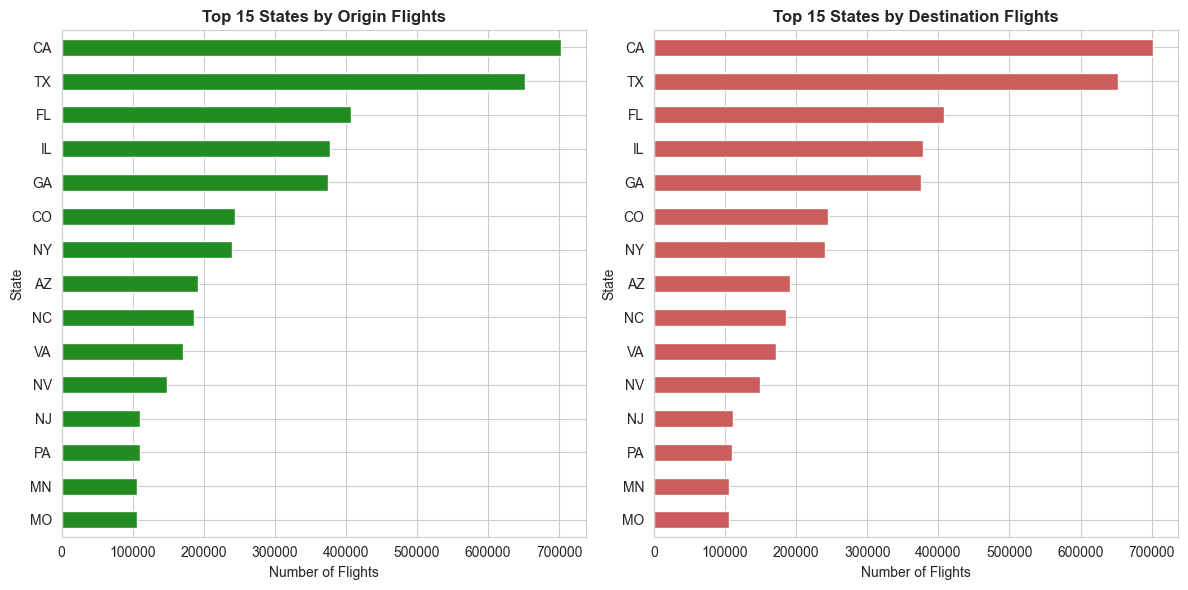

In [19]:
plt.subplot(1, 2, 1)
top_origin_states = df['ORIGIN_STATE_ABR'].value_counts().head(15)
top_origin_states.plot(kind='barh', color='forestgreen')
plt.title('Top 15 States by Origin Flights', fontsize=12, fontweight='bold')
plt.xlabel('Number of Flights')
plt.ylabel('State')
plt.gca().invert_yaxis()

# Top States by Destination Flights
plt.subplot(1, 2, 2)
top_dest_states = df['DEST_STATE_ABR'].value_counts().head(15)
top_dest_states.plot(kind='barh', color='indianred')
plt.title('Top 15 States by Destination Flights', fontsize=12, fontweight='bold')
plt.xlabel('Number of Flights')
plt.ylabel('State')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
print("\n" + "="*60)
print("AIRLINE DATA SUMMARY REPORT")
print("="*60)
print(f"\n📊 Total Flights: {len(df):,}")
print(f"📅 Date Range: {df['FL_DATE'].min()} to {df['FL_DATE'].max()}")
print(f"✈️  Unique Carriers: {df['OP_UNIQUE_CARRIER'].nunique()}")
print(f"🏢 Unique Airports (Origin): {df['ORIGIN'].nunique()}")
print(f"🏢 Unique Airports (Dest): {df['DEST'].nunique()}")
print(f"\n⏱️  On-Time Rate: {(df['DEP_DELAY'] <= 15).sum() / len(df) * 100:.1f}%")
print(f"⏱️  Delayed Rate: {(df['DEP_DELAY'] > 15).sum() / len(df) * 100:.1f}%")
print(f"❌ Cancellation Rate: {df['CANCELLED'].sum() / len(df) * 100:.2f}%")
print(f"\n⏰ Average Departure Delay: {df['DEP_DELAY'].mean():.1f} minutes")
print(f"⏰ Average Arrival Delay: {df['ARR_DELAY'].mean():.1f} minutes")
print(f"📏 Average Flight Distance: {df['DISTANCE'].mean():.0f} miles")
print("\n" + "="*60)


AIRLINE DATA SUMMARY REPORT

📊 Total Flights: 5,591,544
📅 Date Range: 1/1/2012 12:00:00 AM to 9/9/2012 12:00:00 AM
✈️  Unique Carriers: 15
🏢 Unique Airports (Origin): 312
🏢 Unique Airports (Dest): 313

⏱️  On-Time Rate: 82.7%
⏱️  Delayed Rate: 16.0%
❌ Cancellation Rate: 1.32%

⏰ Average Departure Delay: 8.1 minutes
⏰ Average Arrival Delay: 3.5 minutes
📏 Average Flight Distance: 771 miles

